In [13]:
pip install gensim

In [14]:
from gensim.models import Word2Vec

# 1. Create a "Toy" Dataset
sentences = [
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['an', 'apple', 'is', 'a', 'tasty', 'fruit'],
    ['a', 'banana', 'is', 'a', 'tasty', 'fruit'],
    ['an', 'orange', 'is', 'a', 'tasty', 'fruit'],
]

print("---- Training Models ----")

# 2. Train the CBOW Model
model_cbow = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=0,
    epochs=100
)
print("CBOW model trained successfully.")

# 3. Train the Skip-gram Model
model_skipgram = Word2Vec(
    sentences,
    vector_size=10,
    window=2,
    min_count=1,
    sg=1,
    epochs=100
)
print("Skipgram model trained successfully.")

# 4. Define Test Similarities Function
def test_similarities(model, model_name):
    print(f"\n--- Semantic Similarities using {model_name} ---")

    # Compare two related words
    sim_royal = model.wv.similarity('queen', 'king')
    print(f"Similarity ('queen', 'king'): {sim_royal:.4f}")

    # Compare two related words
    sim_fruit = model.wv.similarity('apple', 'banana')
    print(f"Similarity ('apple', 'banana'): {sim_fruit:.4f}")

    # Compare two unrelated words
    sim_unrelated = model.wv.similarity('queen', 'apple')
    print(f"Similarity unrelated words('queen', 'apple'): {sim_unrelated:.4f}")

# 5. Call the function for both trained models
test_similarities(model_cbow, "CBOW")
test_similarities(model_skipgram, "Skip-gram")

---- Training Models ----
CBOW model trained successfully.
Skipgram model trained successfully.

--- Semantic Similarities using CBOW ---
Similarity ('queen', 'king'): 0.4375
Similarity ('apple', 'banana'): -0.1507
Similarity unrelated words('queen', 'apple'): -0.0970

--- Semantic Similarities using Skip-gram ---
Similarity ('queen', 'king'): 0.4364
Similarity ('apple', 'banana'): -0.1492
Similarity unrelated words('queen', 'apple'): -0.0970


In [15]:
!pip install gensim --quiet

import gensim
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [20]:
import gensim.downloader as api

# This automatically downloads and caches the full 1.6GB (compressed)
# dataset directly to Colab
model = api.load("word2vec-google-news-300")

# Test if it works
print(model.most_similar('google'))

[('google.com', 0.6711485981941223), ('google_yahoo', 0.6488178968429565), ('wikipedia', 0.643608033657074), ('www.google.com', 0.6258559226989746), ('googled', 0.6166064143180847), ('googling', 0.6086059212684631), ('slashdot', 0.5964587330818176), ('lifehacker', 0.5948858857154846), ('gizmodo', 0.5884420275688171), ('inurl', 0.5882638692855835)]


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select a few words to visualize
words_to_visualize = [
    'King', 'Queen', 'Man', 'Woman'
]

# Filter out words not in the model's vocabulary
filtered_words = [
    word for word in words_to_visualize
    if word in model.key_to_index
]

# Get the vectors for the filtered words
vectors = [model[word] for word in filtered_words]

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create a scatter plot
plt.figure(figsize=(5, 1))

<Figure size 500x100 with 0 Axes>

<Figure size 500x100 with 0 Axes>

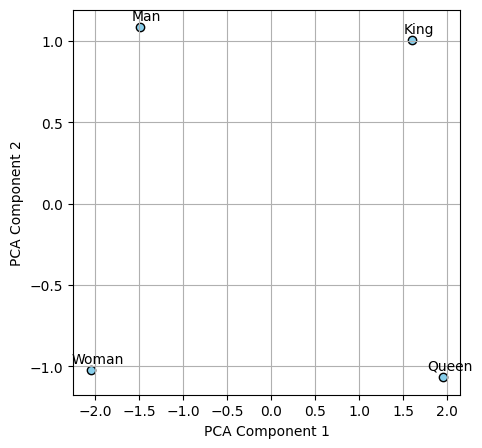

In [21]:
vectors = [model[word] for word in filtered_words]

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create a scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
            edgecolors='k', c='skyblue')

for i, word in enumerate(filtered_words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        ha='center'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

In [22]:
# Perform vector arithmetic: king - man + woman
# This operation is expected to result in a vector close to 'queen'.
result_vector = model['king'] - model['man'] + model['woman']

# Find the words most similar to the result_vector
print("Words most similar to 'king' - 'man' + 'woman':")
similar_words = model.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=5
)

for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Words most similar to 'king' - 'man' + 'woman':
queen: 0.7118
monarch: 0.6190
princess: 0.5902
crown_prince: 0.5499
prince: 0.5377


In [26]:
import plotly.express as px
import pandas as pd

# Create data for Plotly using the filtered words and vectors_2d
data_for_plotly = pd.DataFrame({
    'word': filtered_words,
    'x': vectors_2d[:, 0],
    'y': vectors_2d[:, 1]
})

words = data_for_plotly['word'].tolist()

# Initialize empty similarity matrix
similarity_matrix = pd.DataFrame(index=words, columns=words)

# Populate the matrix using KeyedVectors directly
for i in range(len(words)):
    for j in range(len(words)):
        word1 = words[i]
        word2 = words[j]
        # Call similarity directly on KeyedVectors instance
        similarity_matrix.loc[word1, word2] = model.similarity(word1, word2)

similarity_matrix = similarity_matrix.astype(float)

# Create heatmap
fig = px.imshow(
    similarity_matrix,
    text_auto=".2f",
    aspect="auto",
    title="Cosine Similarity Heatmap for Word Embeddings",
    labels=dict(x="Word 2", y="Word 1", color="Similarity"),
    color_continuous_scale=px.colors.sequential.Viridis
)

# Render figure
fig.show()